# Observed KI67 neighborhoods and crypt position

**Role:** Analysis.

Measure exclusive KI67/TA-cell neighborhood composition and measured curvature across organoid size and collection time, using recorded validation organoids. The visible census and circumference-profile qualification stages distinguish candidate crypt boundaries from supported necks. Existing saved tables can be plotted without inference or training. Small undetectable crypts and unqualified profiles remain explicit missing-support categories; these destructive snapshots do not establish migration or longitudinal development.

In [1]:
from pathlib import Path
import sys
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/models/gnn.py").is_file())  # Locate the repository from the notebook’s working directory.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
ROOT = PROJECT_ROOT  # Repository root used to resolve data and result paths.


## Analysis settings

Choose the input run or cached report and all analysis options here before model loading, inference or plotting. Derived paths and model-dependent defaults are resolved in the following cells; each checkpoint restores its saved data and transformations.

In [2]:
import numpy as np
import torch
from src.analysis.spatial.necks import NeckConfig

# Execution and display
REBUILD_CENSUS = False  # Recompute observed-cell tables before neck qualification.
RUN_ANALYSIS = False  # Recompute analysis tables instead of only reading saved results.

# Analysis configuration
NECK_CONFIG = NeckConfig(
    # Support thresholds
    minimum_crypt_cells=10,  # Minimum cell support for a qualified crypt.

    # Crypt-neck qualification
    minimum_relative_depth=.05,  # Required relative depth of a circumference minimum.
    plateau_max_range=.10,  # Largest allowed circumference variation on a plateau.
    plateau_max_slope=.25,  # Largest allowed absolute plateau slope.
    plateau_exit_rise=.10,  # Required circumference increase after a plateau.
)  # Shape and support thresholds for crypt-neck qualification.

# Input runs, data and destinations
OUTPUT_NAME = 'exclusive_v2_profile_necks'  # Versioned analysis name; change it when changing settings.


## Observed figure definitions

These study-specific definitions build the summaries or panels displayed below. Cohort selection, marker labels, thresholds and figure layouts remain visible here; shared numerical and plotting primitives are imported from `src/`. Defining these functions does not run inference or load results.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from src.analysis.spatial.neighborhoods import BIN_LABELS, MARKERS

OBSERVED_COLORS = {
    'KI67': '#b35806',  # Display color for KI67.
    'LGR5': '#2166ac',  # Display color for LGR5.
    'AldoB': '#359449',  # Display color for AldoB.
}  # Display colors assigned to groups or model variants.

def observed_read(out,name):
    return pd.read_csv(Path(out)/f'{name}.csv')

def observed_axis(ax,ylabel):
    ax.set_xticks(range(6),BIN_LABELS,rotation=30)
    ax.set_xlabel('Observed cell count N (size bins)')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=.15)

def observed_curve(ax,table,metric,label,color,**kw):
    t=table[(table.metric==metric)&table.supported].sort_values('size_bin')
    # Reindex so unsupported intermediate bins are gaps rather than connected lines.
    t=t.set_index('size_bin').reindex(range(6))
    ax.plot(t.index,t['mean'],marker='o',color=color,label=label,**kw)
    ax.fill_between(t.index,t.low,t.high,color=color,alpha=.12)

def observed_overview(out):
    org=observed_read(out,'organoids');summary=observed_read(out,'overview_by_size')
    fig,axs=plt.subplots(1,3,figsize=(12,3.8),layout='constrained')
    counts=pd.crosstab(org.size_bin,org.stratum_time).reindex(range(6),fill_value=0)
    counts.plot.bar(stacked=True,ax=axs[0],colormap='tab10',width=.8)
    axs[0].legend(fontsize=6,title='Collection / batch',title_fontsize=7)
    for metric,label,color in [('full_ki67_fraction','Before exclusion','.5'),('fraction_ki67','Exclusive KI67',OBSERVED_COLORS['KI67'])]:
        observed_curve(axs[1],summary,metric,label,color)
    observed_curve(axs[2],summary,'detected_crypt','At least one detected crypt','#2166ac')
    for a,y in zip(axs,['Number of organoids','Mean fraction of all cells','Fraction of organoids']):observed_axis(a,y)
    axs[1].legend(fontsize=8)
    for a,title in zip(axs,['A  Size and collection-time support','B  Which KI67 population is retained?','C  Crypt-detection support']):a.set_title(title)
    return fig

def observed_measured_curvature(out):
    t=observed_read(out,'profiles_by_size')
    fig,axs=plt.subplots(1,3,figsize=(12,3.8),layout='constrained')
    for marker,color in OBSERVED_COLORS.items():
        for a,metric in zip(axs,['curvature_norm','curvature_rank','negative']):
            observed_curve(a,t[t.marker==marker],metric,marker,color)
    for a,y,title in zip(axs,['Measured K × area / (4π)','Mean within-organoid curvature percentile','Fraction of cells with measured K < 0'],
                        ['A  Size-normalized measured curvature','B  Relative position in curvature distribution','C  Negative Gaussian curvature']):
        observed_axis(a,y);a.set_title(title)
    axs[0].legend(fontsize=8)
    axs[1].axhline(.5,color='.5',ls=':',lw=1)
    return fig

def observed_neighborhood_content(out):
    t=observed_read(out,'profiles_by_size');t=t[t.marker=='KI67']
    fig,axs=plt.subplots(2,2,figsize=(12,7.5),layout='constrained')
    for i,hop in enumerate([1,2]):
        for j,kind in enumerate(['fraction','enrichment']):
            a=axs[i,j]
            matrix=[]
            for m in MARKERS:
                p=t[(t.metric==f'ring{hop}_{kind}_{m}')&t.supported].set_index('size_bin')
                matrix.append(p['mean'].reindex(range(6)).to_numpy())
            matrix=np.asarray(matrix)*100
            limit=max(1,float(np.nanmax(np.abs(matrix))))
            im=a.imshow(matrix,aspect='auto',cmap='Blues' if j==0 else 'RdBu_r',
                vmin=0 if j==0 else -limit,vmax=limit)
            for row in range(len(MARKERS)):
                for col in range(6):
                    v=matrix[row,col]
                    if np.isfinite(v):a.text(col,row,f'{v:.0f}',ha='center',va='center',fontsize=8,
                        color='white' if abs(v)>.65*limit else 'black')
            a.set_yticks(range(len(MARKERS)),MARKERS)
            a.set_xticks(range(6),BIN_LABELS,rotation=30)
            a.set_xlabel('Observed N')
            a.set_title(f'Hop {hop}: '+('neighbor marker fractions' if j==0 else 'excess over organoid composition'))
            fig.colorbar(im,ax=a,label='Percent' if j==0 else 'Percentage points')
    return fig

def observed_crypt_position(out):
    t=observed_read(out,'profiles_by_size');paired=observed_read(out,'ki67_minus_lgr5_by_size')
    conditional=observed_read(out,'ki67_adjacent_lgr5_by_size')
    fig,axs=plt.subplots(1,3,figsize=(12,4),layout='constrained')
    for marker,color in OBSERVED_COLORS.items():
        observed_curve(axs[0],t[t.marker==marker],'fraction_neck_band',marker,color)
        observed_curve(axs[1],t[t.marker==marker],'enrichment_neck_band',marker,color)
    observed_curve(axs[0],conditional,'fraction_neck_band','KI67 adjacent to LGR5',OBSERVED_COLORS['KI67'],ls='--')
    observed_curve(axs[1],conditional,'enrichment_neck_band','KI67 adjacent to LGR5',OBSERVED_COLORS['KI67'],ls='--')
    observed_curve(axs[2],paired,'axis','KI67 − LGR5 (same organoid)',OBSERVED_COLORS['KI67'])
    for a,y,title in zip(axs,['Fraction in estimated neck band','Neck fraction minus all-cell neck fraction','Difference in mean normalized crypt distance'],
        ['A  Locations when a crypt is detected','B  Location enrichment within organoids','C  KI67 farther from crypt base than LGR5?']):
        observed_axis(a,y);a.set_title(title)
    if (Path(out)/'neck_support.csv').exists():
        axs[0].set_title('A  Only circumference-qualified crypt territories')
        axs[1].set_ylabel('Neck fraction minus eligible-territory cell fraction')
    for a in axs[1:]:a.axhline(0,color='.5',ls=':',lw=1)
    axs[0].legend(fontsize=8)
    return fig

def observed_lgr5_neighbors(out):
    t=observed_read(out,'lgr5_contrasts_by_size')
    fig,axs=plt.subplots(1,3,figsize=(12,4.1),layout='constrained')
    for a,metric in zip(axs[:2],['curvature_norm','axis']):
        stratum='qualified_all' if metric=='axis' and 'qualified_all' in t.stratum.values else 'all'
        observed_curve(a,t[t.stratum==stratum],metric,'Within the same organoid','#2166ac')
    for stratum,color in [('crypt_body','#2166ac'),('neck_band','#b35806'),('beyond_neck','#359449'),('no_detected_crypt','.5')]:
        observed_curve(axs[2],t[t.stratum==stratum],'curvature_norm',stratum.replace('_',' '),color)
    for a,y,title in zip(axs,['Difference in measured K × area / (4π)','Difference in normalized crypt distance','Difference in measured K × area / (4π)'],
        ['A  LGR5 with KI67 nearby − without','B  Is that LGR5 cell nearer the neck?','C  Curvature contrast within position bands']):
        observed_axis(a,y);a.set_title(title);a.axhline(0,color='.5',lw=.8)
    axs[2].legend(fontsize=7)
    if (Path(out)/'neck_support.csv').exists():
        axs[1].set_title('B  Position within qualified crypt territories')
        axs[2].set_title('C  Qualified bands; no-detected-crypt separate')
    return fig

def observed_neck_profile_audit(out):
    registry=observed_read(out,'crypt_profile_registry')
    profiles=pd.read_csv(Path(out)/'circumference_profiles.csv.gz')
    support=observed_read(out,'neck_support')
    fig,axs=plt.subplots(2,2,figsize=(11,7),layout='constrained')
    for ax,kind,title in zip(axs.ravel()[:3],['local_minimum','flat_section','no_neck_support'],
                            ['Local-minimum profiles','Approximately flat sections','Profiles without neck support']):
        candidates=registry[registry.profile_class==kind]
        chosen=candidates.sample(min(12,len(candidates)),random_state=1841)
        for row in chosen.itertuples():
            part=profiles[(profiles.organoid_str==row.organoid_str)&(profiles.crypt_id==row.crypt_id)]
            ax.plot(part.s,part.circumference/np.interp(1,part.s,part.circumference),alpha=.5,lw=1)
        ax.axvspan(.8,1.2,color='.7',alpha=.2)
        ax.axvline(1,color='.3',ls=':',lw=1)
        ax.set_xlim(.4,1.6);ax.set_xlabel('Normalized crypt coordinate s')
        ax.set_ylabel('Circumference / C(1)')
        ax.set_title(f'{title} ({len(candidates):,} crypts)')
    a=axs[1,1]
    for column,label,color in [('detected_organoids','Any detected crypt','.6'),
                                ('eligible_organoids','Qualified crypt with ≥10 cells','#2166ac'),
                                ('ki67_organoids','KI67 in a qualified territory','#b35806')]:
        a.plot(support.size_bin,support[column],marker='o',label=label,color=color)
    observed_axis(a,'Number of organoids');a.set_title('Support after individual-crypt qualification')
    a.legend(fontsize=8)
    return fig

def observed_time_checks(out):
    t=observed_read(out,'profiles_size_within_time');t=t[t.marker=='KI67']
    fig,axs=plt.subplots(1,3,figsize=(12,4),layout='constrained')
    for (stratum,p),color in zip(t.groupby('stratum_time'),plt.get_cmap('tab10').colors):
        for a,metric in zip(axs,['curvature_rank','axis','ring1_fraction_LGR5']):
            observed_curve(a,p,metric,stratum,color)
    for a,y,title in zip(axs,['Mean within-organoid curvature percentile','Mean normalized crypt distance','Fraction of hop-1 neighbors that are LGR5'],
        ['A  KI67 curvature within collection / batch','B  KI67 position within collection / batch','C  KI67 neighborhood within collection / batch']):
        observed_axis(a,y);a.set_title(title)
    axs[0].legend(fontsize=6)
    axs[1].axhline(1,color='.5',ls=':',lw=.8)
    return fig

## Rebuild the observed-cell census when needed

The following visible sequence measures fates, curvature and exact-hop composition from the recorded validation organoids. It precedes circumference-profile qualification; its unqualified boundary bands are not themselves evidence of a neck. Existing completed tables can be loaded without rebuilding.

In [4]:
from dataclasses import asdict
import json
from src.analysis.spatial.neighborhoods import ObservedConfig, adjacency_rings, ring_average, neck_regions, within_organoid_contrast, bootstrap_summary, add_adjacent_lgr5_checks

def run_observed_census(root, config=ObservedConfig()):
    root = Path(root)
    run_dir = root / 'results_experiments/size_conditioned_exclusive/20260914_ordered_exclusive_film_depth2/exclusive'
    out = root / 'results_experiments/ki67_observed_neighborhoods/exclusive_v1'
    out.mkdir(parents=True, exist_ok=True)
    settings = json.loads((run_dir/'settings.json').read_text())
    data = root/'training_data'/settings['DATASET_NAME']
    original = root/'training_data'/'after_cleanup'
    metadata = json.loads(json.dumps(dict(config=asdict(config), dataset=str(data), run=str(run_dir))))
    if (out/'settings.json').exists() and json.loads((out/'settings.json').read_text()) != metadata:
        raise ValueError('Settings differ; use a new versioned output directory')
    (out/'settings.json').write_text(json.dumps(metadata, indent=2))
    if (out/'complete.json').exists():
        add_adjacent_lgr5_checks(out, config)
        return out
    membership = pd.read_csv(run_dir/'tables/split_membership.csv').query("role == 'val'")
    assert not membership.organoid_str.duplicated().any()
    all_nodes, organoids, contrasts = [], [], []
    for index, row in enumerate(membership.itertuples()):
        org = row.organoid_str
        meta = json.loads((data/f'{org}_aux.json').read_text())
        with np.load(data/f'{org}.npz', allow_pickle=False) as z:
            x, y, edges = z['x'], z['y'][:, 0], z['edges']
            d = z['d_crypts_graph']
        assert json.loads((data/f'{org}_markers.json').read_text()) == MARKERS[:-1]
        n = len(x)
        assert n == row.n_cells and np.all((x == 0) | (x == 1)) and np.all(x.sum(1) <= 1)
        assert d.ndim == 2 and d.shape[1] == n and np.isfinite(d).all()
        with np.load(original/f'{org}.npz', allow_pickle=False) as z:
            full_x = z['x']; np.testing.assert_array_equal(y, z['y'][:, 0])
            np.testing.assert_array_equal(edges, z['edges'])
        assert full_x.shape == x.shape
        area = float(meta['total_surface_area'])
        assert np.isfinite(area) and area > 0
        axis = d.min(0) if len(d) else np.full(n, np.nan)
        region = neck_regions(axis, config.neck_low, config.neck_high)
        fate = np.c_[x, x.sum(1) == 0].astype(float)
        names = np.asarray(MARKERS)[fate.argmax(1)]
        bin_id = int(np.searchsorted(config.size_edges, n, side='right')-1)
        # Keep collection label and biological day separate; day4p5-more is not later than day4p5.
        day = {'day3p5': 3.5, 'day4': 4., 'day4p5': 4.5, 'day4p5-more': 4.5}[meta['timepoint']]
        common = dict(organoid_str=org, n=n, size_bin=bin_id, timepoint=meta['timepoint'], day=day,
                      dataset=str(meta['dataset']), stratum_time=f"{meta['dataset']} / {meta['timepoint']}")
        frame = pd.DataFrame(dict(node=np.arange(n), marker=names, curvature=y,
            curvature_norm=y*area/(4*np.pi), curvature_centered=(y-y.mean())*area/(4*np.pi),
            curvature_rank=pd.Series(y).rank(method='average', pct=True), negative=(y<0).astype(float),
            axis=axis, region=region))
        frame = frame.assign(**common)
        for label in ['crypt_body', 'neck_band', 'beyond_neck']:
            frame[f'fraction_{label}'] = np.where(np.isfinite(axis), region == label, np.nan)
            frame[f'enrichment_{label}'] = frame[f'fraction_{label}'] - frame[f'fraction_{label}'].mean()
        for hop, adj in enumerate(adjacency_rings(edges, n), 1):
            frame[f'ring{hop}_degree'] = np.asarray(adj.sum(1)).ravel()
            fractions = ring_average(adj, fate)
            expected = (fate.sum(0)[None, :] - fate)/(n-1)
            for j, marker in enumerate(MARKERS):
                frame[f'ring{hop}_fraction_{marker}'] = fractions[:, j]
                frame[f'ring{hop}_enrichment_{marker}'] = fractions[:, j] - expected[:, j]
            frame[f'ring{hop}_curvature_norm'] = ring_average(adj, y*area/(4*np.pi))
            frame[f'ring{hop}_curvature_rank'] = ring_average(adj, frame.curvature_rank.to_numpy())
        frame['has_ki67_neighbor'] = frame.ring1_fraction_KI67 > 0
        frame['mixed_lgr5_aldob_neighbors'] = ((frame.ring1_fraction_LGR5 > 0) & (frame.ring1_fraction_AldoB > 0)).astype(float)
        for contrast in within_organoid_contrast(frame[frame.marker == 'LGR5'], config.minimum_lgr5_per_group):
            contrasts.append(common | contrast)
        full_ki = int(full_x[:, MARKERS.index('KI67')].sum())
        retained_ki = int(x[:, MARKERS.index('KI67')].sum())
        organoids.append(common | dict(n_crypts=len(d), n_ki67=retained_ki, n_lgr5=int((names=='LGR5').sum()),
            fraction_ki67=retained_ki/n, full_ki67_fraction=full_ki/n,
            ki67_retained=retained_ki/full_ki if full_ki else np.nan,
            detected_crypt=float(len(d)>0), surface_area=area))
        all_nodes.append(frame)
        if (index+1)%100 == 0:
            print(f'Observed census: {index+1}/{len(membership)} organoids', flush=True)
    nodes = pd.concat(all_nodes, ignore_index=True)
    organs = pd.DataFrame(organoids)
    paired = pd.DataFrame(contrasts)
    nodes.to_csv(out/'nodes.csv.gz', index=False)
    organs.to_csv(out/'organoids.csv', index=False)
    paired.to_csv(out/'lgr5_with_minus_without_ki67.csv', index=False)
    group_cols = ['organoid_str', 'n', 'size_bin', 'timepoint', 'day', 'dataset', 'stratum_time', 'marker']
    metrics = [c for c in nodes.select_dtypes(include=np.number).columns if c not in ['node','n','size_bin','day']]
    profiles = nodes.groupby(group_cols, observed=True)[metrics].mean().reset_index()
    profiles['n_centers'] = nodes.groupby(group_cols, observed=True).size().to_numpy()
    profiles.to_csv(out/'organoid_marker_profiles.csv', index=False)
    for name, groups in [('profiles_by_size',['marker','size_bin']), ('profiles_by_time',['marker','stratum_time']),
                         ('profiles_size_within_time',['marker','stratum_time','size_bin'])]:
        bootstrap_summary(profiles, groups, metrics, config).to_csv(out/f'{name}.csv',index=False)
    overview_metrics=['fraction_ki67','full_ki67_fraction','ki67_retained','detected_crypt']
    bootstrap_summary(organs,['size_bin'],overview_metrics,config).to_csv(out/'overview_by_size.csv',index=False)
    contrast_metrics=['curvature','curvature_norm','curvature_rank','negative','axis','ring1_fraction_AldoB','ring1_fraction_LGR5']
    for name, groups in [('lgr5_contrasts_by_size',['stratum','size_bin']), ('lgr5_contrasts_by_time',['stratum','stratum_time'])]:
        bootstrap_summary(paired,groups,contrast_metrics,config).to_csv(out/f'{name}.csv',index=False)
    # KI67 vs LGR5 in the SAME organoid controls for changing whole-organoid geometry/composition.
    pair_metrics=['curvature_norm','curvature_rank','axis','fraction_neck_band','enrichment_neck_band']
    ki = profiles[profiles.marker=='KI67'].set_index('organoid_str')
    lg = profiles[profiles.marker=='LGR5'].set_index('organoid_str')
    ids=ki.index.intersection(lg.index)
    diffs=ki.loc[ids,['n','size_bin','stratum_time']].copy()
    diffs[pair_metrics]=ki.loc[ids,pair_metrics]-lg.loc[ids,pair_metrics]
    diffs=diffs.reset_index()
    diffs.to_csv(out/'ki67_minus_lgr5_paired.csv',index=False)
    bootstrap_summary(diffs,['size_bin'],pair_metrics,config).to_csv(out/'ki67_minus_lgr5_by_size.csv',index=False)
    (out/'complete.json').write_text(json.dumps(dict(organoids=len(organs), cells=len(nodes),
        ki67_cells=int((nodes.marker=='KI67').sum()), ki67_organoids=int((organs.n_ki67>0).sum()),
        detected_crypt_organoids=int(organs.detected_crypt.sum()),
        lgr5_paired_organoids=int(paired[paired.stratum=='all'].organoid_str.nunique())), indent=2))
    print('Observed KI67 analysis complete', flush=True)
    add_adjacent_lgr5_checks(out, config)
    return out

In [5]:
if REBUILD_CENSUS:
    run_observed_census(ROOT)

# Observed neighborhoods and positions of exclusive KI67 cells

**Question:** does KI67 identify a different spatial context as organoid size increases—particularly a neck location near LGR5 cells—rather than a direct curvature-inducing interaction?

This notebook analyzes **observed graphs and measured Gaussian curvature**, with no GNN inference, marker removals, or retraining. It uses all 1,100 organoids from the existing exclusive-marker FiLM experiment, retaining its sphericity and blacklist filters. Every eligible cell is used; there is no center subsampling. The earlier PCA notebook is retained separately.

N is the **observed number of cells**, never a supplied counterfactual size. Prespecified bins are `<150`, `150–249`, `250–349`, `350–499`, `500–799`, and `≥800`. Collection time and dataset are retained separately: `day4p5-more` is another collection label at day 4.5, not a later biological day. We cannot track individual cells or crypts between these destructive snapshots.

**Revised positional analysis:** s=1 alone is not evidence of a neck. The pipeline can normalize to an inflection point when no minimum exists. Figures 4–6 now qualify each individual crypt from its circumference profile before interpreting positional coordinates. Figures 1–3 and the all-cell curvature comparison in Figure 5A do not depend on this qualification.

In [6]:
from src.artifacts.provenance import workflow_fingerprint
from dataclasses import dataclass
import shutil
from scipy.signal import savgol_filter, find_peaks
from src.analysis.spatial.necks import classify_profile, qualified_assignment
WORKFLOW_SOURCE = PROJECT_ROOT / 'experiments/neighborhoods/ki67_observed_neighborhoods.ipynb'  # Notebook used when recording the code fingerprint.


### Run

The study sequence is defined here; shared numerical operations are imported above.

In [7]:
def run_neck_analysis(root, config=NeckConfig(), *, output_name='exclusive_v2_profile_necks'):
    root=Path(root)
    source=root/'results_experiments/ki67_observed_neighborhoods/exclusive_v1'
    out=source.parent/output_name;out.mkdir(exist_ok=True)
    original_settings=json.loads((source/'settings.json').read_text())
    settings=json.loads(json.dumps(dict(source=str(source),neck_config=asdict(config),original=original_settings)))
    if (out/'settings.json').exists() and json.loads((out/'settings.json').read_text())!=settings:
        raise ValueError('Neck settings changed; use a separate output version')
    (out/'settings.json').write_text(json.dumps(settings,indent=2))
    if (out/'complete.json').exists():return out
    data=Path(original_settings['dataset'])
    stats_config=ObservedConfig()
    nodes=pd.read_csv(source/'nodes.csv.gz')
    organs=pd.read_csv(source/'organoids.csv')
    registry=[];profile_rows=[];node_parts=[];variants=[]
    for counter,(org,frame) in enumerate(nodes.groupby('organoid_str',sort=True)):
        frame=frame.sort_values('node').copy();n=len(frame)
        meta=json.loads((data/f'{org}_aux.json').read_text())
        with np.load(data/f'{org}.npz',allow_pickle=False) as z:
            distances=z['d_crypts_graph'];projection=z['proj_vertex_ids']
        # Trusted locally produced segmentation object arrays. Only numerical arrays are used.
        with np.load(meta['segmentation_path'],allow_pickle=True) as z:
            s=z['d_discretized'];cc=z['circumference_crypts'];lengths=z['L_crypts']
            np.testing.assert_allclose(distances,z['d_crypts'][:,projection],rtol=2e-6,atol=2e-6)
        assert len(cc)==len(distances)==len(lengths)
        nearest,_=qualified_assignment(distances,np.ones(len(distances),bool))
        records=[]
        for k,c in enumerate(cc):
            diagnostics=classify_profile(s,c,config)
            interior_count=int(np.sum((nearest==k)&(distances[k]<=1)))
            passes_shape=diagnostics['profile_class'] in ['local_minimum','flat_section']
            row=dict(organoid_str=org,crypt_id=k,size_bin=int(frame.size_bin.iloc[0]),n=n,
                crypt_length=float(lengths[k]),crypt_cells=interior_count,shape_pass=passes_shape,
                eligible=passes_shape and interior_count>=config.minimum_crypt_cells,**diagnostics)
            row['status']='low_cell_support' if passes_shape and not row['eligible'] else row['profile_class']
            records.append(row);registry.append(row)
            for x,y in zip(s,c):profile_rows.append(dict(organoid_str=org,crypt_id=k,s=x,circumference=y))
        passing=[r['eligible'] for r in records]
        nearest,axis=qualified_assignment(distances,passing)
        # Missing positions include absent, unqualified and low-support crypts.
        frame['nearest_crypt_id']=nearest;frame['unqualified_axis']=frame.axis
        frame['axis']=axis;valid=np.isfinite(axis)
        frame['qualified_neck']=valid
        frame['region']=np.select([~valid,axis<.8,axis<=1.2],
            ['unqualified_crypt','crypt_body','neck_band'],default='beyond_neck')
        if not len(distances):frame['region']='no_detected_crypt'
        frame['crypt_profile_class']=[records[k]['status'] if k>=0 else 'no_detected_crypt' for k in nearest]
        for label in ['crypt_body','neck_band','beyond_neck']:
            value=np.where(valid,frame.region==label,np.nan)
            frame[f'fraction_{label}']=value
            frame[f'enrichment_{label}']=value-np.nanmean(value) if valid.any() else value
        node_parts.append(frame)
        # Sensitivity to cell support, keeping the same shape criterion and original assignment.
        for cell_threshold in [5,10,20]:
            _,ax=qualified_assignment(distances,[r['shape_pass'] and r['crypt_cells']>=cell_threshold for r in records])
            mask=np.isfinite(ax)
            if not mask.any():continue
            for width in [.1,.2,.3]:
                band=(ax>=1-width)&(ax<=1+width)
                for cohort,sel in [('KI67',(frame.marker=='KI67').to_numpy()),
                                   ('KI67_adjacent_LGR5',((frame.marker=='KI67')&(frame.ring1_fraction_LGR5>0)).to_numpy())]:
                    if not (mask&sel).any():continue
                    variants.append(dict(organoid_str=org,size_bin=int(frame.size_bin.iloc[0]),cohort=cohort,
                        minimum_cells=cell_threshold,half_width=width,fraction=band[mask&sel].mean(),
                        enrichment=band[mask&sel].mean()-band[mask].mean()))
        if (counter+1)%200==0:print(f'Profile audit: {counter+1}/{len(organs)} organoids',flush=True)
    revised=pd.concat(node_parts,ignore_index=True)
    crypts=pd.DataFrame(registry)
    crypts.to_csv(out/'crypt_profile_registry.csv',index=False)
    pd.DataFrame(profile_rows).to_csv(out/'circumference_profiles.csv.gz',index=False)
    revised.to_csv(out/'nodes.csv.gz',index=False)
    groups=['organoid_str','n','size_bin','timepoint','day','dataset','stratum_time','marker']
    metrics=['axis','fraction_crypt_body','fraction_neck_band','fraction_beyond_neck',
             'enrichment_crypt_body','enrichment_neck_band','enrichment_beyond_neck']
    profiles=revised.groupby(groups)[metrics].mean().reset_index()
    profiles.to_csv(out/'qualified_organoid_marker_profiles.csv',index=False)
    # Existing nonpositional measurements remain exactly as originally computed.
    for name in ['organoids.csv','overview_by_size.csv','lgr5_contrasts_by_time.csv']:
        shutil.copyfile(source/name,out/name)
    for name,grouping in [('profiles_by_size',['marker','size_bin']),('profiles_size_within_time',['marker','stratum_time','size_bin'])]:
        original=pd.read_csv(source/f'{name}.csv')
        replacement=bootstrap_summary(profiles,grouping,metrics,stats_config)
        pd.concat([original[~original.metric.isin(metrics)],replacement],ignore_index=True).to_csv(out/f'{name}.csv',index=False)
    relevant=revised[(revised.marker=='KI67')&(revised.ring1_fraction_LGR5>0)]
    conditional=relevant.groupby(['organoid_str','size_bin'])[metrics].mean().reset_index()
    bootstrap_summary(conditional,['size_bin'],metrics,stats_config).to_csv(out/'ki67_adjacent_lgr5_by_size.csv',index=False)
    ki=profiles[profiles.marker=='KI67'].set_index('organoid_str');lg=profiles[profiles.marker=='LGR5'].set_index('organoid_str')
    ids=ki.index.intersection(lg.index)
    paired=ki.loc[ids,['size_bin']].copy();paired[metrics]=ki.loc[ids,metrics]-lg.loc[ids,metrics]
    bootstrap_summary(paired.reset_index(),['size_bin'],metrics,stats_config).to_csv(out/'ki67_minus_lgr5_by_size.csv',index=False)
    contrasts=[]
    for org,frame in revised[revised.marker=='LGR5'].groupby('organoid_str'):
        common=dict(organoid_str=org,size_bin=int(frame.size_bin.iloc[0]))
        # "all" retains the unchanged curvature comparison; its axis is intentionally missing.
        for row in within_organoid_contrast(frame,stats_config.minimum_lgr5_per_group):
            if row['stratum']=='all':row['axis']=np.nan
            contrasts.append(common|row)
        qualifying=frame[frame.qualified_neck]
        for row in within_organoid_contrast(qualifying,stats_config.minimum_lgr5_per_group):
            if row['stratum']=='all':
                row['stratum']='qualified_all';contrasts.append(common|row)
    measures=['curvature','curvature_norm','curvature_rank','negative','axis','ring1_fraction_AldoB','ring1_fraction_LGR5']
    bootstrap_summary(pd.DataFrame(contrasts),['stratum','size_bin'],measures,stats_config).to_csv(out/'lgr5_contrasts_by_size.csv',index=False)
    bootstrap_summary(pd.DataFrame(variants),['cohort','minimum_cells','half_width','size_bin'],['fraction','enrichment'],stats_config).to_csv(out/'neck_sensitivity.csv',index=False)
    support=[]
    for b,g in organs.groupby('size_bin'):
        c=crypts[crypts.size_bin==b];f=revised[revised.size_bin==b]
        support.append(dict(size_bin=b,organoids=len(g),detected_organoids=int(g.detected_crypt.sum()),crypts=len(c),
            shape_pass=int(c.shape_pass.sum()),eligible_crypts=int(c.eligible.sum()),eligible_organoids=c[c.eligible].organoid_str.nunique(),
            ki67_organoids=f[(f.marker=='KI67')&f.qualified_neck].organoid_str.nunique()))
    pd.DataFrame(support).to_csv(out/'neck_support.csv',index=False)
    (out/'complete.json').write_text(json.dumps(dict(crypts=len(crypts),shape_counts=crypts.profile_class.value_counts().to_dict(),
        eligible_crypts=int(crypts.eligible.sum()),eligible_organoids=int(crypts[crypts.eligible].organoid_str.nunique())),indent=2))
    return out

In [8]:
from IPython.display import display, Markdown
# Study-specific functions are defined in this notebook.


# Paths and outputs
OUTPUT = ROOT / 'results_experiments/ki67_observed_neighborhoods' / OUTPUT_NAME  # Directory containing the selected analysis results.

# Execution switches
if RUN_ANALYSIS:
    from threadpoolctl import threadpool_limits
    with threadpool_limits(limits=4):
        OUTPUT = run_neck_analysis(ROOT, NECK_CONFIG, output_name=OUTPUT_NAME)
assert (OUTPUT / 'complete.json').exists()
assert json.loads((OUTPUT / 'settings.json').read_text())['neck_config'] == json.loads(json.dumps(asdict(NECK_CONFIG)))
FIGURES = OUTPUT / 'figures'  # Destination for the generated figures.
FIGURES.mkdir(exist_ok=True)
plt.rcParams.update({'font.size': 9, 'axes.titlesize': 10, 'figure.dpi': 120})
def show(fig, name):
    fig.savefig(FIGURES / f'{name}.png', dpi=170, bbox_inches='tight')
    fig.savefig(FIGURES / f'{name}.pdf', bbox_inches='tight')
    plt.show(); plt.close(fig)
print(json.dumps(json.loads((OUTPUT / 'complete.json').read_text()), indent=2))


{
  "crypts": 2171,
  "shape_counts": {
    "no_neck_support": 1746,
    "local_minimum": 299,
    "flat_section": 126
  },
  "eligible_crypts": 414,
  "eligible_organoids": 315
}


## Figure 1 — What is represented in each size bin?

A shows organoid counts by collection label and dataset. B distinguishes the original binary KI67 signal from the exclusive KI67 population; fate exclusion changes the biological population being described. C shows how frequently at least one crypt was detected.

All subsequent means first average eligible cells **within each organoid**, then give organoids equal weight. Bands are 95% organoid bootstrap intervals, describing organoid variability conditional on the observed datasets and processing. They are not uncertainty across independent experimental batches. Estimates with fewer than ten organoids are omitted from plots. Per-metric support counts are exported in the summary tables.

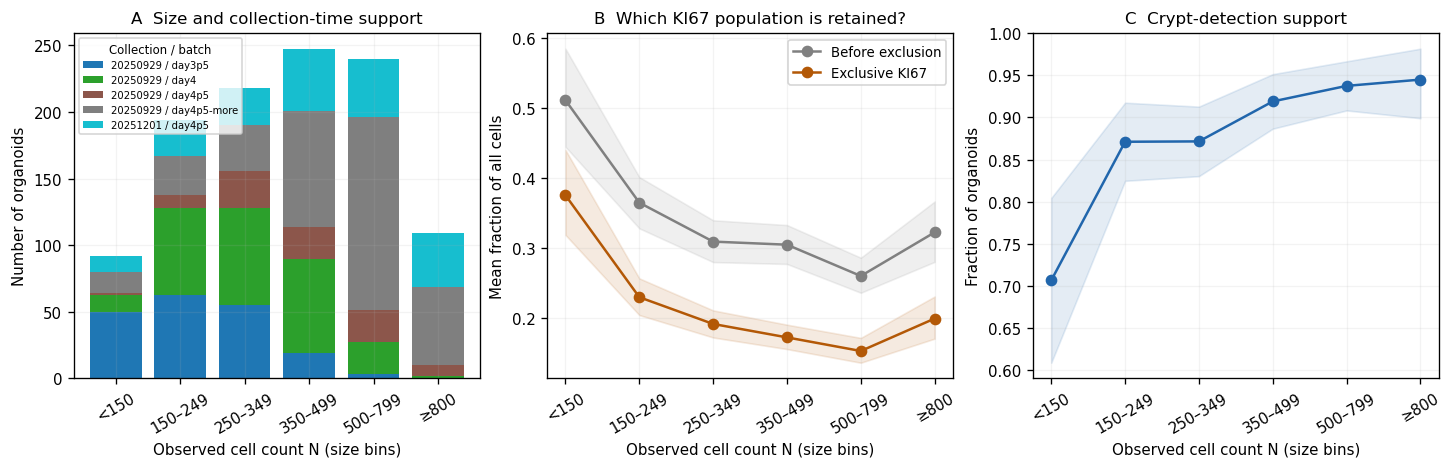

In [9]:
show(observed_overview(OUTPUT), 'figure_1_support')

## Figure 2 — Measured curvature of KI67, LGR5 and AldoB cells

A uses \(K A_{\rm organoid}/(4\pi)\), with the **measured surface area of that organoid**, not the fitted size–area reference used for counterfactual sweeps. This is dimensionless and equals one for a sphere. No learned baseline or inverse model transform is involved. B ranks measured curvature among all cells of the same organoid, providing a comparison less sensitive to extreme values and overall size. C reports the fraction with negative Gaussian curvature.

The exported graph curvature is used before the training pipeline's additional target outlier interpolation. Cells from different marker groups can have different organoid support; the saved `ki67_minus_lgr5_by_size.csv` provides paired, same-organoid comparisons.

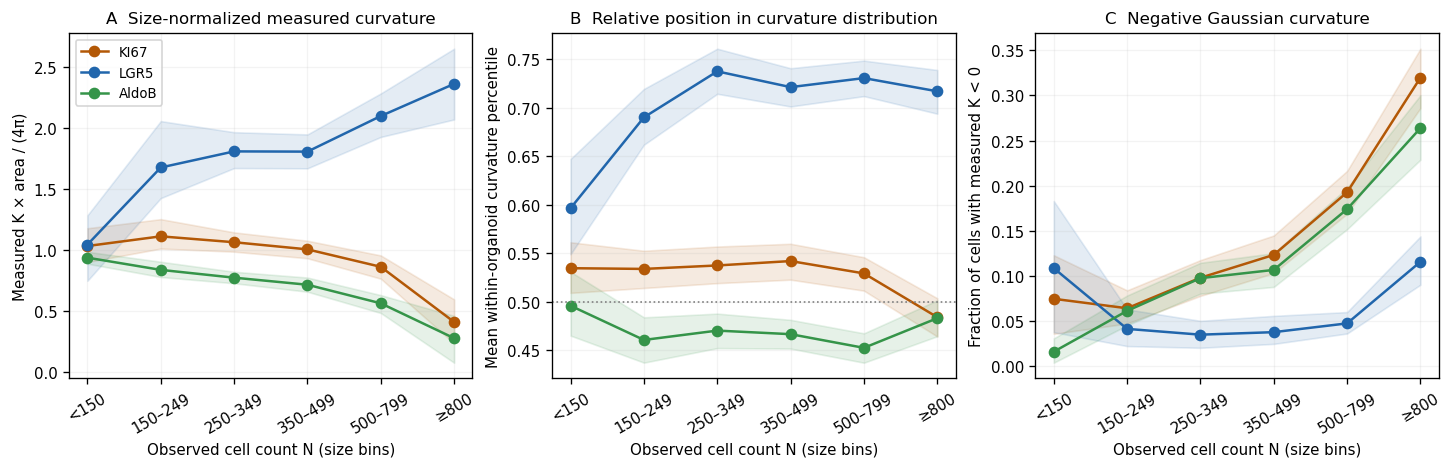

In [10]:
show(observed_measured_curvature(OUTPUT), 'figure_2_measured_curvature')

## Figure 3 — Typical neighborhoods of KI67 cells

The center is an **exclusive KI67 cell**, whereas in the previous ablation study the center was LGR5. Here we characterize the KI67 population directly, and Figure 5 returns to LGR5 recipients.

Left: neighbor fate composition in exact hop-1 and hop-2 rings; neither ring includes the center, and hop 2 excludes hop 1. Right: percentage-point excess over the composition expected from uniformly selecting other cells in that same organoid, excluding the center. This controls descriptively for changing marker abundance across N. It is a composition reference, not a significance test or a fitted spatial null model. Unmarked cells are retained as a category.

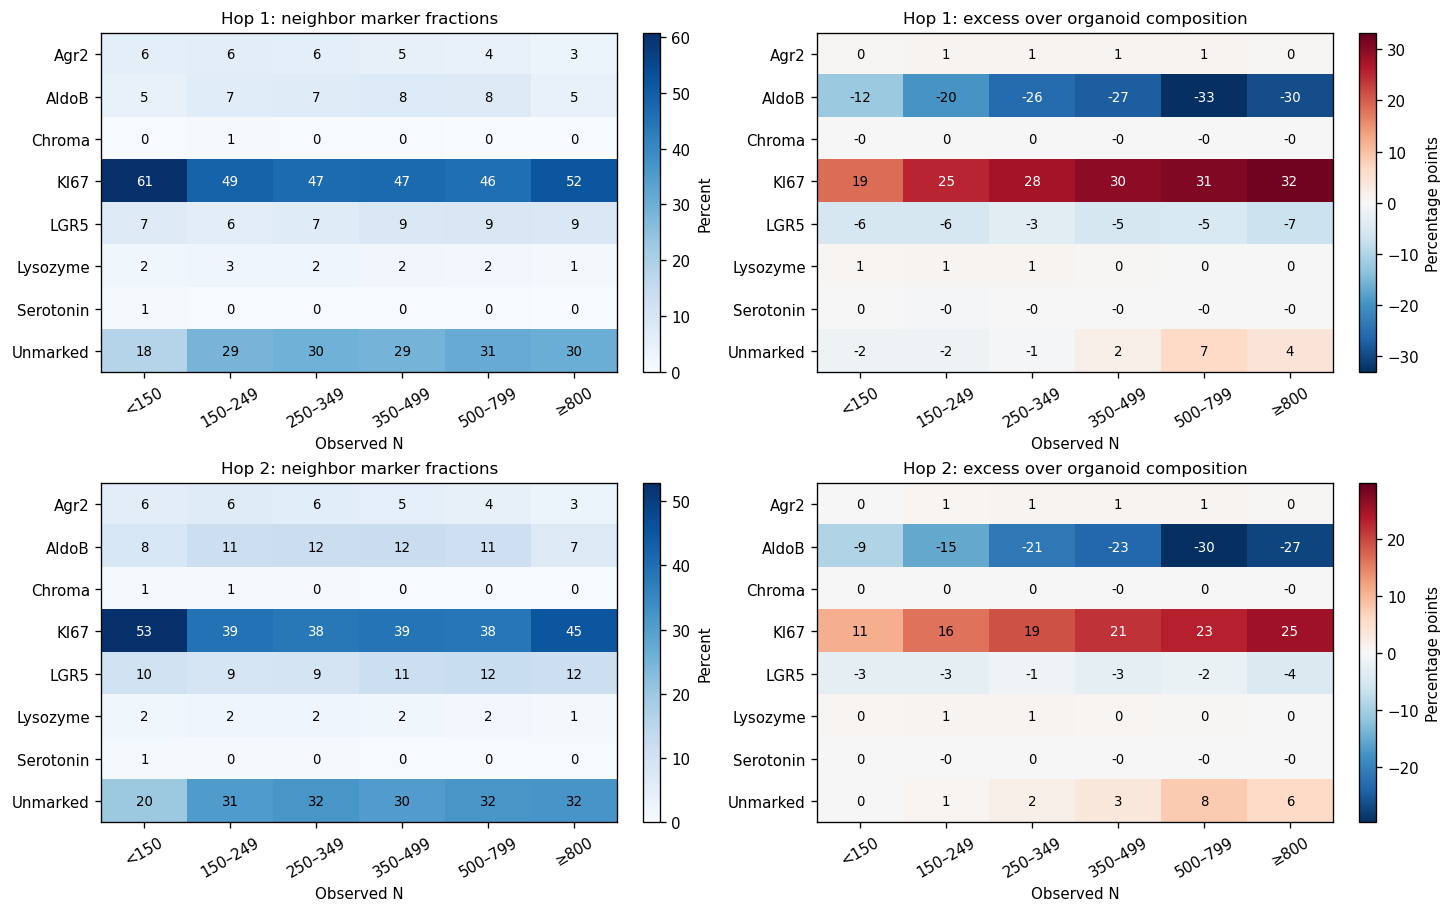

In [11]:
show(observed_neighborhood_content(OUTPUT), 'figure_3_ki67_neighborhoods')

## Figure 4A — Qualifying the neck and showing what is excluded

The saved `circumference_crypts` curves and `d_discretized` grid are read from each organoid's segmentation file. Their crypt rows are checked against the exported graph distances at each projected cell vertex. Classification uses **circumference only**, with no fate or curvature response as a criterion.

Default operational rules, exposed above:

- Normalize circumference by C(1); apply a seven-sample, quadratic Savitzky–Golay smoother.
- **Minimum:** a local minimum within 0.8–1.2, with both shoulders higher by at least 5% of C(1), using shoulders at least 0.1 away within 0.5–1.5.
- **Flat section:** over 0.85–1.15, circumference range ≤10% of C(1) and absolute fitted slope ≤0.25 C(1) per unit s. The median circumference at 1.3–1.5 must rise by at least 10% of C(1), avoiding a flat dome top being called a tube.
- Require finite positive coverage of 0.5–1.5. Profiles failing quality checks are unresolved. Other profiles are labelled **no neck support**, not proven bulges.
- Require at least **10 graph cells assigned to the crypt within s≤1**. This is a sampling-support threshold, not a validated maturity or detection-reliability cutoff. Sensitivity tables repeat the analysis at 5 and 20 cells and for neck half-widths 0.1, 0.2 and 0.3.

The examples below show up to twelve reproducibly sampled **raw** normalized circumference profiles per shape class, including any subsequently excluded for low cell support. These criteria are transparent morphological proxies, not a manually validated budded/bulged classifier. Their strictness can be changed in `NECK_CONFIG` using a new output version.

Small crypts that were never detected cannot enter any class. Low support at small N is therefore a limitation on inference, not evidence that early necks do not exist.

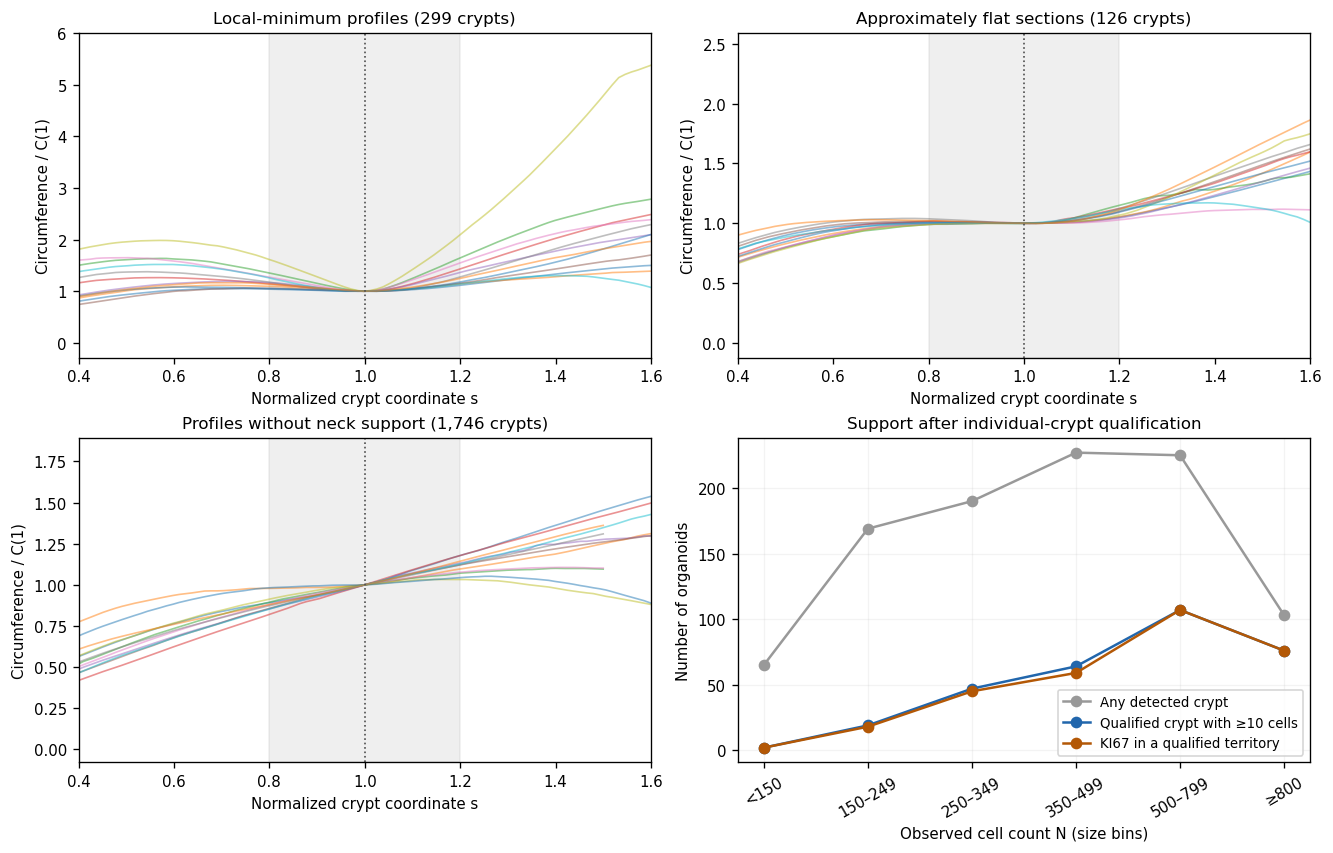

,size_bin,organoids,detected_organoids,crypts,shape_pass,eligible_crypts,eligible_organoids,ki67_organoids
0,0,92,65,129,4,2,2,2
1,1,194,169,370,22,21,19,18
2,2,218,190,391,54,53,47,45
3,3,247,227,515,82,77,64,59
4,4,240,225,501,141,141,107,107
5,5,109,103,265,122,120,76,76


In [12]:
show(observed_neck_profile_audit(OUTPUT), 'figure_4a_circumference_qualification')
display(pd.read_csv(OUTPUT / 'neck_support.csv'))

## Figure 4B — KI67 position around qualified necks

Only cells whose **original nearest normalized-distance crypt** passes the circumference and sampling criteria enter these positional summaries. Cells assigned to a nonqualifying crypt are excluded; they are not reassigned to a farther qualifying crypt. The normalization coordinate remains the original exported s, with no re-centering during this analysis.

Within a qualified crypt territory, `s<0.8` denotes body, `0.8≤s≤1.2` the neck band, and `s>1.2` beyond the band. The latter is not automatically a villus. Territory membership uses the minimum normalized distance across all originally detected crypts, so comparisons are conditional on that operational partition.

A shows neck fractions among eligible cells of each marker. The dashed line restricts KI67 to cells directly adjacent to LGR5. B subtracts the neck fraction of **all cells in the same qualified territories of that organoid**, rather than mixing in excluded crypts. C compares the mean s of KI67 and LGR5 within the same organoid, requiring both markers to have qualified positions. Group differences need not be within the same individual crypt.

The very small-N positional result is omitted because only two organoids qualify. Missing or undetected immature crypts remain unknown; the filter cannot recover them. The earlier claim of progressively increasing KI67 neck enrichment was based on mixing qualified necks and other shapes and is superseded by this analysis.

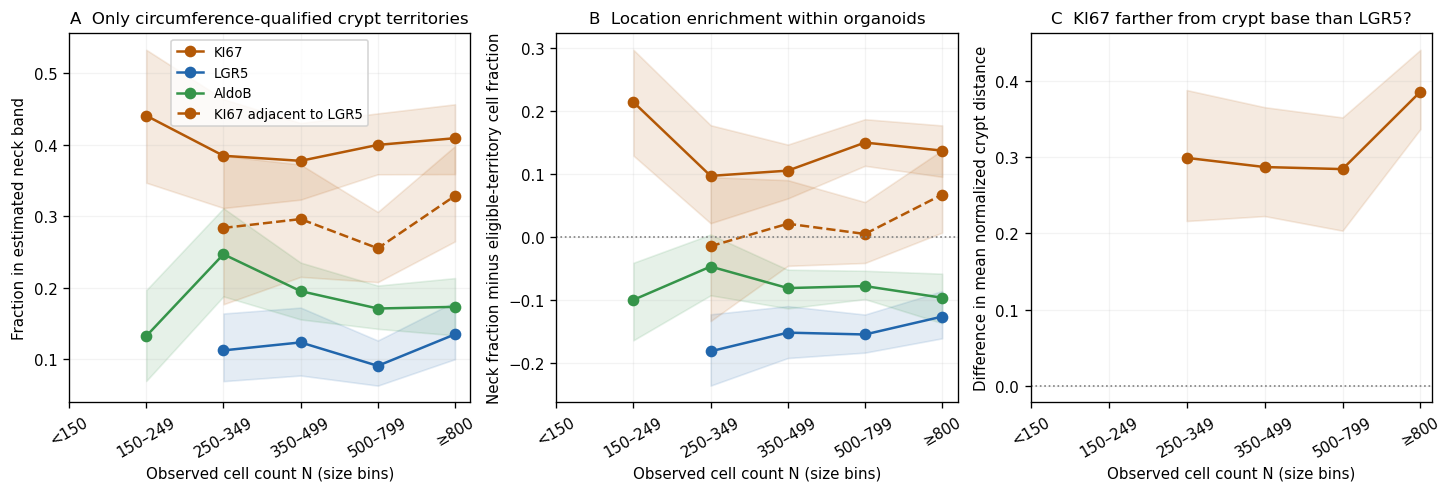

In [13]:
show(observed_crypt_position(OUTPUT), 'figure_4_crypt_positions')

## Figure 5 — Does nearby KI67 mark a different LGR5 location?

A retains the original within-organoid measured-curvature contrast: **LGR5 cells with at least one KI67-positive hop-1 neighbor minus LGR5 cells without one**. Both groups must contain at least three cells. It uses all eligible LGR5 cells and makes no assumption about crypt shape.

B independently applies that eligibility requirement within circumference-qualified crypt territories, then compares their mean s. Positive means farther from the base, not necessarily closer to the neck for cells already beyond it. C compares curvature within qualified body/neck/beyond bands; organoids with no detected crypt provide a separate nonpositional control. Cells assigned to nonqualifying crypts do not enter the named positional bands.

These comparisons involve different observed LGR5 cells, not marker ablations. Coarse position bands cannot isolate an interaction or perfectly match spatial position. Intervals reflect organoid resampling, not independent experiments.

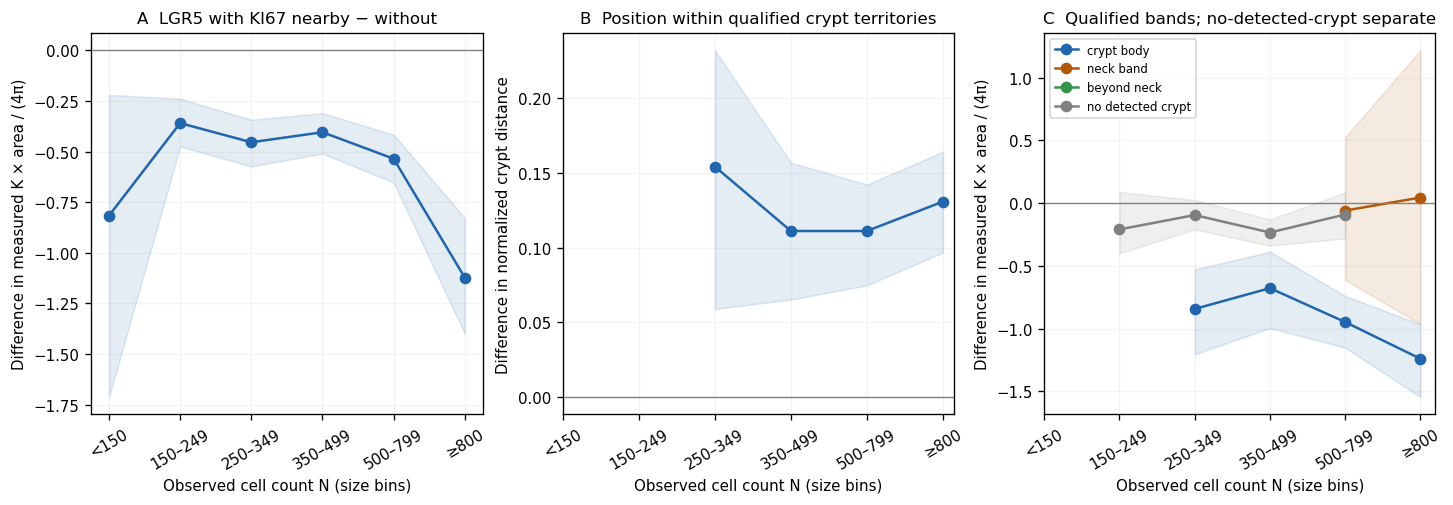

In [14]:
show(observed_lgr5_neighbors(OUTPUT), 'figure_5_lgr5_with_without_ki67')

## Figure 6 — Does the size pattern also appear within collection times?

Repeat the KI67 profiles across N separately for each dataset/collection label, showing curvature percentile, crypt-axis position, and LGR5 neighbor fraction. Gaps reflect insufficient support. These comparisons expose possible time/batch mixing; they are not a causal adjustment or a longitudinal analysis. The small-N extremes and crypt-detection requirement should be read together with Figure 1.

Only panel B uses the circumference-qualified positional subset. Panels A and C retain all exclusive KI67 cells, so support differs between panels. Qualified small-N data are sparse and omitted below ten organoids.

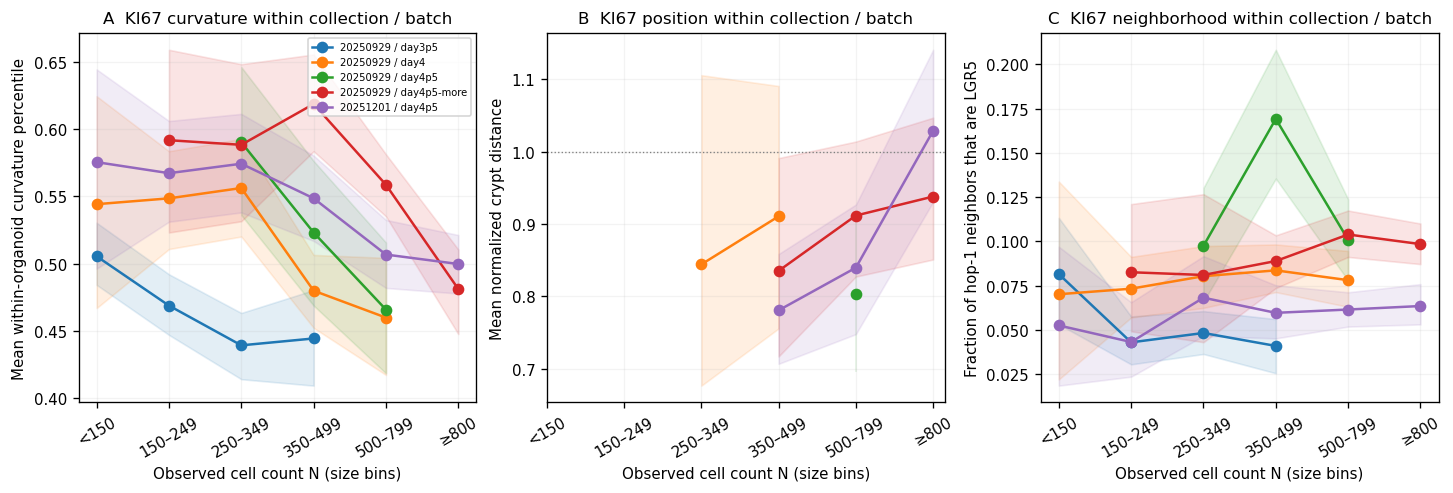

In [15]:
show(observed_time_checks(OUTPUT), 'figure_6_collection_checks')

## Reading the results together

The analysis asks three distinct questions: **where KI67 cells occur**, **what neighborhoods they occupy**, and **whether nearby KI67 identifies lower-curvature LGR5 cells**. None requires the GNN to be correct.

The observed associations can support a positional interpretation of the learned signal without reproducing a fixed-graph ablation sweep. In particular, changing which LGR5 cell is observed is different from removing KI67 from a selected neighbor while preserving every other feature and edge. A discrepancy between those comparisons is informative, but does not by itself falsify either result.

Raw per-cell data, organoid profiles, support counts, contrasts, sensitivity checks, and figure files are saved in the output directory. The report below summarizes the completed results and their limits.

In [16]:
report = OUTPUT / 'REPORT.md'
if report.exists(): display(Markdown(report.read_text()))

# KI67 positions after circumference-based neck qualification

**The previous interpretation of every s≈1 band as a neck was too broad.** The segmentation code can place an inflection point at one when it finds no circumference minimum. Positional conclusions from the original analysis are superseded by the results below. Observed curvature and neighborhood-composition measurements that do not use crypt position are unaffected.

## What changed

Each detected crypt is now classified independently from its saved circumference profile. Circumference is normalized by C(1) and lightly smoothed. Qualification requires either a local minimum in s=0.8–1.2 with at least 5% two-sided shoulder recovery, or a persistent approximately flat section over 0.85–1.15 followed by expansion toward 1.3–1.5. The latter avoids calling a flat dome top a tubular neck. Full criteria and representative raw profiles are displayed in Figure 4A of `experiments/ki67_observed_neighborhoods.ipynb`.

These are operational shape criteria, not validated anatomical labels. Profiles without evidence for a neck are not automatically labelled bulges. A second requirement of at least ten graph cells assigned inside s≤1 excludes poorly sampled crypts; this is not a guarantee of detection accuracy or maturity. Cells keep their original nearest-crypt assignment: excluded crypts never donate their cells to farther qualifying crypts. All positional summaries, position-stratified curvature contrasts and positional time checks use this qualification.

## Support

Of **2,171 detected crypts**, 299 have qualifying minima and 126 qualifying flat sections. After the sampling requirement, **414 crypts in 315 organoids** remain. The other 1,746 profiles lack neck support under the default shape rule; eleven shape-qualified crypts fail the cell-support requirement.

| Observed N | Organoids with any detected crypt | Organoids with a qualified crypt | With KI67 in a qualified territory |
| --- | ---: | ---: | ---: |
| <150 | 65 | 2 | 2 |
| 150–249 | 169 | 19 | 18 |
| 250–349 | 190 | 47 | 45 |
| 350–499 | 227 | 64 | 59 |
| 500–799 | 225 | 107 | 107 |
| ≥800 | 103 | 76 | 76 |

**There is insufficient support for an early-small-N neck-location conclusion.** Undetected immature crypts are missing observations, not neck-free or villus observations. The absence of qualifying small-N samples cannot establish absence of early necks.

## Revised findings

**KI67 is enriched near qualified necks across the supported size bins, without a clear progressive increase with N — Figure 4B.** The organoid-weighted fraction of KI67 cells in the neck band is approximately 44%, 38%, 38%, 40% and 41% across N=150–249 through N≥800. Subtracting the neck fraction of all cells in the same qualified territories gives enrichments of +21, +10, +11, +15 and +14 percentage points. All corresponding pointwise 95% organoid-bootstrap intervals exclude zero. These compare selected crypt territories and do not estimate whole-organoid KI67 migration.

**The KI67 cells immediately adjacent to LGR5 behave differently from the full KI67 population.** Their enrichment is −1.4 percentage points around N=250–349 (95% interval −13.3 to +9.5), +0.5 at N=500–799 (−4.1 to +5.6), and +6.8 at N≥800 (+0.7 to +13.8). Thus a general KI67 neck preference still cannot be assumed for all sources in the earlier LGR5-centered ablation experiment. The ≥800 bin extends beyond the earlier N=700 sweep endpoint.

**The nonpositional result remains: LGR5 cells with KI67 neighbors have lower measured curvature across sizes — Figure 5A.** That within-organoid comparison does not use s and is unchanged. It remains relevant to the positional-information hypothesis, but differs from removing a marker from a fixed neighborhood. The exact anatomical interpretation of position-stratified contrasts must now be restricted to the qualified subset (Figure 5B–C).

Sampling-support sensitivity at 5, 10 and 20 cells preserves the broad qualified-KI67 enrichment pattern while small-N support stays insufficient. Narrower and wider neck-band results are exported in `neck_sensitivity.csv`. These checks do not validate the shape thresholds themselves; Figure 4A makes the selected and rejected profiles reviewable. Seven focused tests passed, including trough/plateau discrimination, rejection of a flat dome, and preservation of the original nearest-crypt assignment. Saved mesh-to-graph distance projections were verified for every organoid.

The earlier suggestion of progressively increasing neck localization should therefore be replaced with a narrower conclusion: **KI67 preferentially occupies neck regions when a sufficiently sampled, circumference-qualified neck is present, while its developmental relocation remains unresolved.**
